In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# read data
data = pd.read_csv('data_PitchConverter.csv')
data.head()


,Country,WF,WTG,Generation,Type,Power,Component,Material Code,Material Description,'Consumption'[Date],Age (d),Sum of Q,Unit,Order,Order Exchange
0,Poland,WFG-PO-03,90567,SIGMA,N100,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2015-01-01 00:00:00,1,1,PCE,SYN-ORD-738550,SYN-EX-01
1,Turkey,WFG-TU-03,87868,SIGMA,N100,2500,Pitch Converter,R33318,frequency converter Pitchmaster2+E40,2025-10-31 00:00:00,299,1,PCE,SYN-ORD-961404,SYN-EX-06
2,Sweden,WFG-SW-03,90089,SIGMA,N90,2500,Generator,GEN-4201,Generator control module,2020-09-18 00:00:00,300,1,PCE,SYN-ORD-969772,SYN-EX-05
3,Ireland,WFG-IR-02,89164,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2021-06-27 00:00:00,306,1,PCE,SYN-ORD-863497,SYN-EX-07
4,Germany,WFG-GE-03,89720,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2024-01-23 00:00:00,316,1,PCE,SYN-ORD-805998,SYN-EX-09


In [3]:
print('Number of rowsa in data:', data.shape[0])
print('Number of columns in data:', data.shape[1])

Number of rowsa in data: 10517
Number of columns in data: 15


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10517 entries, 0 to 10516
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Country               10517 non-null  object
 1   WF                    10517 non-null  object
 2   WTG                   10517 non-null  int64 
 3   Generation            10517 non-null  object
 4   Type                  10517 non-null  object
 5   Power                 10517 non-null  int64 
 6   Component             10517 non-null  object
 7   Material Code         10517 non-null  object
 8   Material Description  10517 non-null  object
 9   'Consumption'[Date]   10517 non-null  object
 10  Age (d)               10517 non-null  int64 
 11  Sum of Q              10517 non-null  int64 
 12  Unit                  10517 non-null  object
 13  Order                 10517 non-null  object
 14  Order Exchange        10517 non-null  object
dtypes: int64(4), object(11)
memory usage

In [5]:
data['WTG'] = data['WTG'].astype('object')
data['Order'] = data['Order'].astype('object')
data["'Consumption'[Date]"] = pd.to_datetime(data["'Consumption'[Date]"])

In [6]:
data.describe()

,Power,'Consumption'[Date],Age (d),Sum of Q
count,10517.000000,10517,10517.000000,10517.000000
mean,2788.979747,2021-05-01 05:43:23.898450176,2213.813160,1.119996
min,1300.000000,2015-01-01 00:00:00,1.000000,1.000000
25%,2500.000000,2019-07-23 00:00:00,1350.000000,1.000000
50%,2500.000000,2021-06-15 00:00:00,1926.000000,1.000000
75%,2500.000000,2023-04-09 00:00:00,2750.000000,1.000000
max,6800.000000,2025-10-31 00:00:00,7611.000000,22.000000
std,720.983170,NaN,1224.836351,0.474789


# Dataset Overview:

* 10,517 records in total with 4 numeric columns being analyzed

## Power (kW):

- Mean: 2,789 kW | Most turbines operate at 2,500 kW (median/mode)
- Range: 1,300 - 6,800 kW
- Std Dev: ~721 kW (moderate variability)
- 75% of data is at 2,500 kW, suggesting most turbines are standard capacity

# Consumption Date:
- Data spans from Jan 2015 to Oct 2025 (~10.8 years)
- Average date is May 2021
- Age (d) - Age in days:

- Mean: 2,214 days (~6 years)
- Range: 1 - 7,611 days (~20.8 years)
- Median: 1,926 days (~5.3 years)
- This indicates a mix of newer and older turbines in the fleet

# Sum of Q (Consumption quantity):

- Mean: 1.12 | Most values are 1.0 (75th percentile)
- Max: 22, indicating some outliers with much higher consumption
- Low std dev (0.48) shows most data clusters around 1.0, with occasional spikes

# Key Insights:

- The data is relatively uniform (75% at mode values), suggesting consistent turbine types
- Age varies widely, indicating diverse fleet composition
- Most consumption is standardized at Q=1, with occasional high-consumption events worth investigating

In [7]:
data.columns

Index(['Country', 'WF', 'WTG', 'Generation', 'Type', 'Power', 'Component',
       'Material Code', 'Material Description', ''Consumption'[Date]',
       'Age (d)', 'Sum of Q', 'Unit', 'Order', 'Order Exchange'],
      dtype='object')

In [8]:
data['Country'].groupby(data['Country']).count().sort_values(ascending=False)

Country
Germany           2004
France            1835
Turkey            1235
USA                950
United Kingdom     897
Ireland            575
Italy              374
Poland             305
Portugal           301
Netherlands        263
Finland            259
Sweden             222
Uruguay            179
Belgium            152
Greece             133
South Africa       131
Spain              114
Norway             101
Croatia             97
Lithuania           77
Pakistan            74
Argentina           55
Brazil              54
Estonia             47
Romania             34
Luxembourg          26
Czechia             21
Chile                2
Name: Country, dtype: int64

In [9]:
data.head()

,Country,WF,WTG,Generation,Type,Power,Component,Material Code,Material Description,'Consumption'[Date],Age (d),Sum of Q,Unit,Order,Order Exchange
0,Poland,WFG-PO-03,90567,SIGMA,N100,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2015-01-01,1,1,PCE,SYN-ORD-738550,SYN-EX-01
1,Turkey,WFG-TU-03,87868,SIGMA,N100,2500,Pitch Converter,R33318,frequency converter Pitchmaster2+E40,2025-10-31,299,1,PCE,SYN-ORD-961404,SYN-EX-06
2,Sweden,WFG-SW-03,90089,SIGMA,N90,2500,Generator,GEN-4201,Generator control module,2020-09-18,300,1,PCE,SYN-ORD-969772,SYN-EX-05
3,Ireland,WFG-IR-02,89164,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2021-06-27,306,1,PCE,SYN-ORD-863497,SYN-EX-07
4,Germany,WFG-GE-03,89720,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2024-01-23,316,1,PCE,SYN-ORD-805998,SYN-EX-09


In [10]:
data['Age (years)'] = data['Age (d)'] / 365
data['Age (years)'] = data['Age (years)'].round(2)
data['year'] = data["'Consumption'[Date]"].dt.year
data['month'] = data["'Consumption'[Date]"].dt.month
data['day'] = data["'Consumption'[Date]"].dt.day
data.head()

,Country,WF,WTG,Generation,Type,Power,Component,Material Code,Material Description,'Consumption'[Date],Age (d),Sum of Q,Unit,Order,Order Exchange,Age (years),year,month,day
0,Poland,WFG-PO-03,90567,SIGMA,N100,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2015-01-01,1,1,PCE,SYN-ORD-738550,SYN-EX-01,0.00,2015,1,1
1,Turkey,WFG-TU-03,87868,SIGMA,N100,2500,Pitch Converter,R33318,frequency converter Pitchmaster2+E40,2025-10-31,299,1,PCE,SYN-ORD-961404,SYN-EX-06,0.82,2025,10,31
2,Sweden,WFG-SW-03,90089,SIGMA,N90,2500,Generator,GEN-4201,Generator control module,2020-09-18,300,1,PCE,SYN-ORD-969772,SYN-EX-05,0.82,2020,9,18
3,Ireland,WFG-IR-02,89164,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2021-06-27,306,1,PCE,SYN-ORD-863497,SYN-EX-07,0.84,2021,6,27
4,Germany,WFG-GE-03,89720,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2024-01-23,316,1,PCE,SYN-ORD-805998,SYN-EX-09,0.87,2024,1,23


In [11]:
# create a table showing the number of unique WTG and sum of q and avg age  per Country

country_summary = data.groupby('Country').agg(
    unique_WTG=('WTG', 'nunique'),
    total_consumption=('Sum of Q', 'sum'),
    avg_age_d=('Age (d)', 'mean'),
    avg_age_y=('Age (years)', 'mean')
).sort_values(by=['unique_WTG', 'total_consumption'], ascending=False).reset_index()

country_summary['avg_age_d'] = country_summary['avg_age_d'].round(2)
country_summary['avg_age_y'] = country_summary['avg_age_y'].round(2)

In [12]:
country_summary['CI_country'] = (country_summary['total_consumption'] / country_summary['unique_WTG']).round(2)

In [13]:
country_summary

,Country,unique_WTG,total_consumption,avg_age_d,avg_age_y,CI_country
0,Germany,1688,2217,2214.82,6.07,1.31
1,France,1547,2064,2206.57,6.05,1.33
2,Turkey,1118,1414,2169.12,5.94,1.26
3,USA,872,1044,2231.95,6.11,1.20
4,United Kingdom,824,996,2241.95,6.14,1.21
5,Ireland,555,649,2314.76,6.34,1.17
6,Italy,364,421,2287.98,6.27,1.16
7,Poland,300,340,2273.32,6.23,1.13
8,Portugal,292,333,2090.07,5.73,1.14
9,Netherlands,255,313,2191.67,6.00,1.23


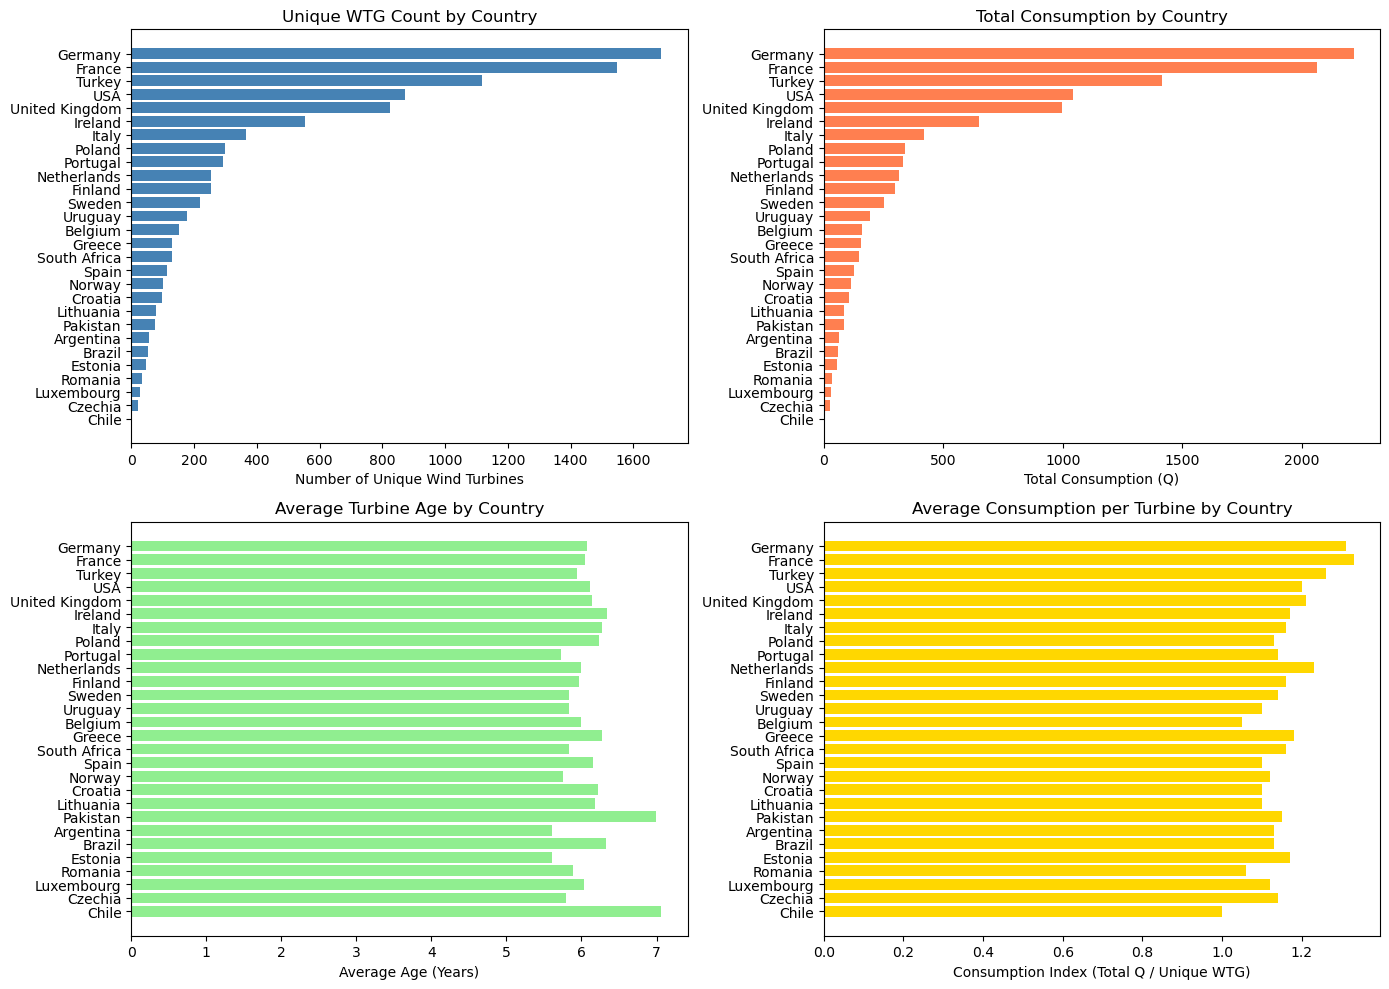

In [14]:
# Visualize country summary with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Unique WTG by Country
axes[0, 0].barh(country_summary['Country'], country_summary['unique_WTG'], color='steelblue')
axes[0, 0].set_xlabel('Number of Unique Wind Turbines')
axes[0, 0].set_title('Unique WTG Count by Country')
axes[0, 0].invert_yaxis()

# Plot 2: Total Consumption by Country
axes[0, 1].barh(country_summary['Country'], country_summary['total_consumption'], color='coral')
axes[0, 1].set_xlabel('Total Consumption (Q)')
axes[0, 1].set_title('Total Consumption by Country')
axes[0, 1].invert_yaxis()

# Plot 3: Average Age (years) by Country
axes[1, 0].barh(country_summary['Country'], country_summary['avg_age_y'], color='lightgreen')
axes[1, 0].set_xlabel('Average Age (Years)')
axes[1, 0].set_title('Average Turbine Age by Country')
axes[1, 0].invert_yaxis()

# Plot 4: Consumption Index (CI_country) by Country
axes[1, 1].barh(country_summary['Country'], country_summary['CI_country'], color='gold')
axes[1, 1].set_xlabel('Consumption Index (Total Q / Unique WTG)')
axes[1, 1].set_title('Average Consumption per Turbine by Country')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Display the table
#print("\n" + "="*100)
#print("COUNTRY SUMMARY TABLE")
#print("="*100)
#print(country_summary.to_string(index=False))

* High CI_country = Higher consumption per turbine (potential maintenance issues or intensive use)
* High avg_age_y = Older fleet (may correlate with higher consumption)
* Country comparison = Which countries have the oldest turbines and highest consumption patterns

In [15]:
#creater z-score column for total consumption, avg age d and avg age y, and CI_country
country_summary['z_score_total_consumption'] = (country_summary['total_consumption'] - country_summary['total_consumption'].mean()) / country_summary['total_consumption'].std()
country_summary['z_score_avg_age_d'] = (country_summary['avg_age_d'] - country_summary['avg_age_d'].mean()) / country_summary['avg_age_d'].std()
country_summary['z_score_avg_age_y'] = (country_summary['avg_age_y'] - country_summary['avg_age_y'].mean()) / country_summary['avg_age_y'].std()
country_summary['z_score_CI_country'] = (country_summary['CI_country'] - country_summary['CI_country'].mean()) / country_summary['CI_country'].std()
country_summary

,Country,unique_WTG,total_consumption,avg_age_d,avg_age_y,CI_country,z_score_total_consumption,z_score_avg_age_d,z_score_avg_age_y,z_score_CI_country
0,Germany,1688,2217,2214.82,6.07,1.31,3.020100,-0.039330,-0.031752,2.209748
1,France,1547,2064,2206.57,6.05,1.33,2.762866,-0.106154,-0.091021,2.489084
2,Turkey,1118,1414,2169.12,5.94,1.26,1.670041,-0.409493,-0.417005,1.511408
3,USA,872,1044,2231.95,6.11,1.20,1.047971,0.099420,0.086788,0.673399
4,United Kingdom,824,996,2241.95,6.14,1.21,0.967270,0.180418,0.175692,0.813067
5,Ireland,555,649,2314.76,6.34,1.17,0.383870,0.770166,0.768389,0.254395
6,Italy,364,421,2287.98,6.27,1.16,0.000540,0.553253,0.560945,0.114727
7,Poland,300,340,2273.32,6.23,1.13,-0.135642,0.434510,0.442406,-0.304277
8,Portugal,292,333,2090.07,5.73,1.14,-0.147411,-1.049784,-1.039336,-0.164609
9,Netherlands,255,313,2191.67,6.00,1.23,-0.181037,-0.226841,-0.239196,1.092404


Correlation between Sum of Q and Age (d): -0.033624588338673427


C:\Users\sivak\AppData\Local\Temp\ipykernel_9420\3405044706.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Country')


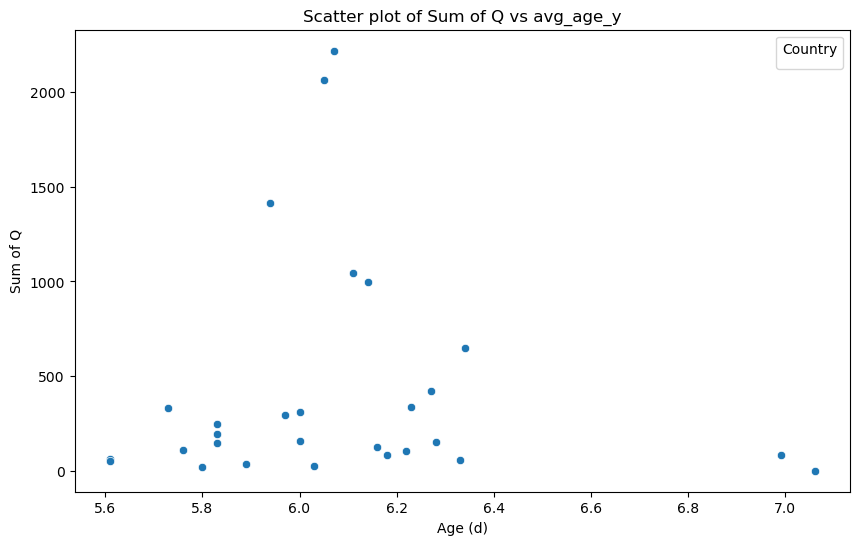

In [16]:
# perform correlation analysis betwwen 'Sum of Q' and 'Age (d)'
correlation = country_summary[['total_consumption', 'avg_age_y']].corr()
print('Correlation between Sum of Q and Age (d):', correlation.loc['total_consumption', 'avg_age_y'])

# visualize the relationship between 'Sum of Q' and 'Age (d)'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=country_summary, x='avg_age_y', y='total_consumption')
plt.title('Scatter plot of Sum of Q vs avg_age_y')
plt.xlabel('Age (d)')
plt.ylabel('Sum of Q')
plt.legend(title='Country')
plt.show()

Correlation between Sum of Q and Age (d): -0.03516249264996186


C:\Users\sivak\AppData\Local\Temp\ipykernel_9420\1104637488.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Country')


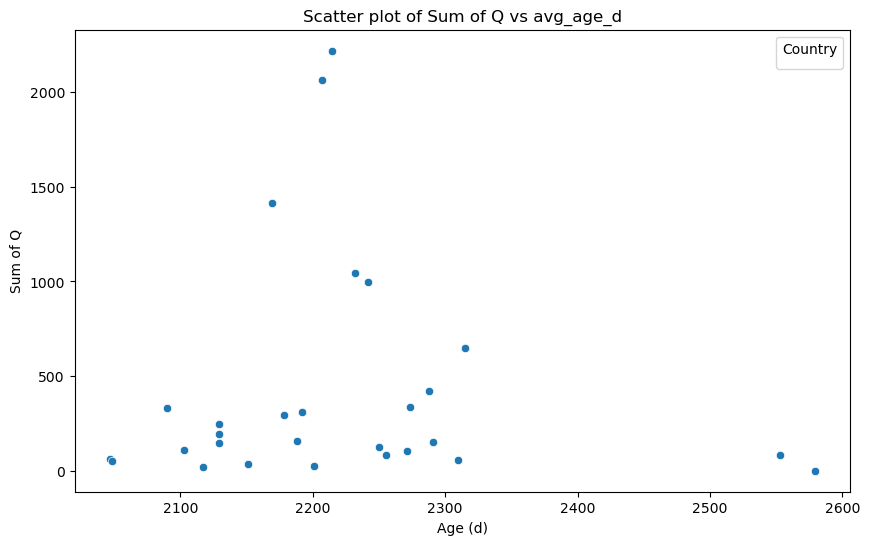

In [17]:
# perform correlation analysis betwwen 'Sum of Q' and 'Age (d)'
correlation = country_summary[['total_consumption', 'avg_age_d']].corr()
print('Correlation between Sum of Q and Age (d):', correlation.loc['total_consumption', 'avg_age_d'])

# visualize the relationship between 'Sum of Q' and 'Age (d)'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=country_summary, x='avg_age_d', y='total_consumption')
plt.title('Scatter plot of Sum of Q vs avg_age_d')
plt.xlabel('Age (d)')
plt.ylabel('Sum of Q')
plt.legend(title='Country')
plt.show()

In [18]:
data_germany = data[data['Country'] == 'Germany']
data_germany.shape

(2004, 19)

In [19]:
data_germany.head()

,Country,WF,WTG,Generation,Type,Power,Component,Material Code,Material Description,'Consumption'[Date],Age (d),Sum of Q,Unit,Order,Order Exchange,Age (years),year,month,day
4,Germany,WFG-GE-03,89720,SIGMA,N90,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2024-01-23,316,1,PCE,SYN-ORD-805998,SYN-EX-09,0.87,2024,1,23
8,Germany,WFG-GE-03,86491,GAMMA,N149,4500,Gearbox,GBX-2044,Gearbox service component,2023-11-24,345,2,PCE,SYN-ORD-976213,SYN-EX-04,0.95,2023,11,24
17,Germany,WFG-GE-03,86819,SIGMA,N100,2500,Pitch Converter,R33318,frequency converter Pitchmaster2+E40,2022-07-08,397,1,PCE,SYN-ORD-959016,SYN-EX-09,1.09,2022,7,8
27,Germany,WFG-GE-03,88312,SIGMA,N100,2500,Pitch Converter,R39803-03,frequency converter Pitchmaster2+E40,2020-04-22,440,1,PCE,SYN-ORD-757319,SYN-EX-05,1.21,2020,4,22
28,Germany,WFG-GE-03,88324,SIGMA,N100,2500,Main Bearing,BRG-2208,Main bearing assembly,2022-05-29,440,1,PCE,SYN-ORD-924708,SYN-EX-07,1.21,2022,5,29


Correlation between Sum of Q and Age (d): -0.015921711072196993


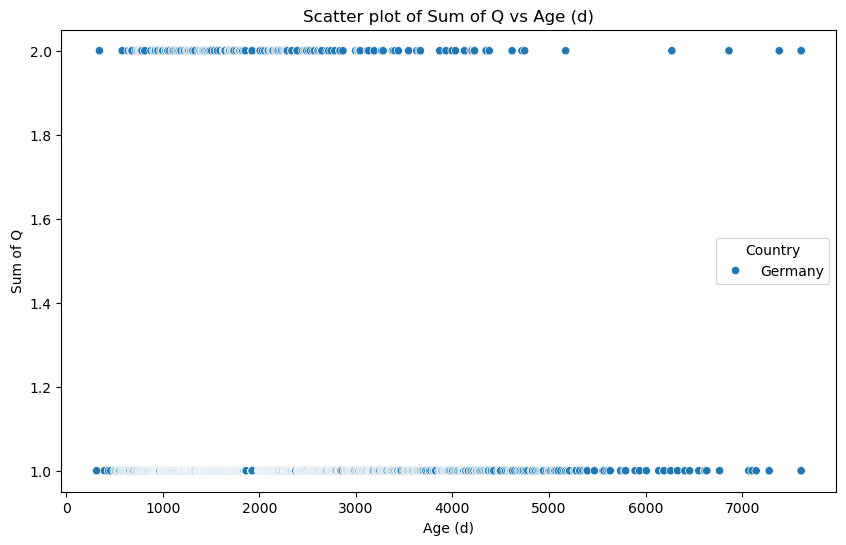

In [20]:
# perform correlation analysis betwwen 'Sum of Q' and 'Age (d)'
correlation = data_germany[['Sum of Q', 'Age (d)']].corr()
print('Correlation between Sum of Q and Age (d):', correlation.loc['Sum of Q', 'Age (d)'])

# visualize the relationship between 'Sum of Q' and 'Age (d)'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_germany, x='Age (d)', y='Sum of Q', hue='Country')
plt.title('Scatter plot of Sum of Q vs Age (d)')
plt.xlabel('Age (d)')
plt.ylabel('Sum of Q')
plt.legend(title='Country')
plt.show()

In [21]:
# Data validation and preprocessing

data['WTG'] = data['WTG'].astype(str)
data['Order'] = data['Order'].astype(str)
data['Power'] = pd.to_numeric(data['Power'], errors='coerce')
data["'Consumption'[Date]"] = pd.to_datetime(data["'Consumption'[Date]"], errors='coerce')
data['Age (years)'] = (data['Age (d)'] / 365).round(2)

print('Missing values by column:')
print(data.isna().sum())
print('\nDuplicate rows:', data.duplicated().sum())
print('\nSample of invalid dates:')
print(data.loc[data["'Consumption'[Date]"].isna(), ["'Consumption'[Date]", 'Country', 'WTG']].head())

print('Unique counts for key categorical fields:')
print(data[['Country', 'WF', 'Generation', 'Type', 'Component', 'Material Description', 'Order']].nunique())


Missing values by column:
Country                 0
WF                      0
WTG                     0
Generation              0
Type                    0
Power                   0
Component               0
Material Code           0
Material Description    0
'Consumption'[Date]     0
Age (d)                 0
Sum of Q                0
Unit                    0
Order                   0
Order Exchange          0
Age (years)             0
year                    0
month                   0
day                     0
dtype: int64

Duplicate rows: 0

Sample of invalid dates:
Empty DataFrame
Columns: ['Consumption'[Date], Country, WTG]
Index: []
Unique counts for key categorical fields:
Country                    28
WF                         27
Generation                  3
Type                        8
Component                   6
Material Description        6
Order                   10365
dtype: int64


In [22]:
# Component and material consumption analysis

component_summary = data.groupby('Component').agg(
    total_consumption=('Sum of Q', 'sum'),
    avg_age_y=('Age (years)', 'mean'),
    unique_turbines=('WTG', 'nunique'),
    records=('WTG', 'count')
).sort_values(by='total_consumption', ascending=False).reset_index()

material_summary = data.groupby('Material Description').agg(
    total_consumption=('Sum of Q', 'sum'),
    avg_age_y=('Age (years)', 'mean'),
    records=('WTG', 'count')
).sort_values(by='total_consumption', ascending=False).reset_index()

print('Top 12 components by total consumption:')
display(component_summary.head(12))

print('Top 12 material descriptions by total consumption:')
display(material_summary.head(12))

Top 12 components by total consumption:


,Component,total_consumption,avg_age_y,unique_turbines,records
0,Pitch Converter,6792,6.060774,3634,6050
1,Generator,1414,6.127654,1156,1279
2,Gearbox,1232,6.137171,979,1085
3,Yaw System,946,5.902859,794,850
4,Hydraulic Unit,747,5.965640,637,672
5,Main Bearing,648,6.196730,555,581


Top 12 material descriptions by total consumption:


,Material Description,total_consumption,avg_age_y,records
0,frequency converter Pitchmaster2+E40,6792,6.060774,6050
1,Generator control module,1414,6.127654,1279
2,Gearbox service component,1232,6.137171,1085
3,Yaw drive frequency converter,946,5.902859,850
4,Hydraulic pitch unit,747,5.965640,672
5,Main bearing assembly,648,6.196730,581


Yearly consumption summary:


,year,total_consumption,count,avg_consumption,avg_age_y
0,2015,94,84,1.119048,5.512024
1,2016,370,328,1.128049,6.225000
2,2017,731,653,1.119449,6.075314
3,2018,1078,957,1.126437,6.065841
4,2019,1354,1185,1.142616,6.202143
5,2020,1501,1360,1.103676,6.019478
6,2021,1641,1443,1.137214,6.058850
7,2022,1665,1497,1.112224,6.036820
8,2023,1569,1406,1.115932,6.107112
9,2024,1223,1110,1.101802,5.981847


C:\Users\sivak\AppData\Local\Temp\ipykernel_9420\671165424.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x='year', y='total_consumption', palette='viridis', ax=axes[0])


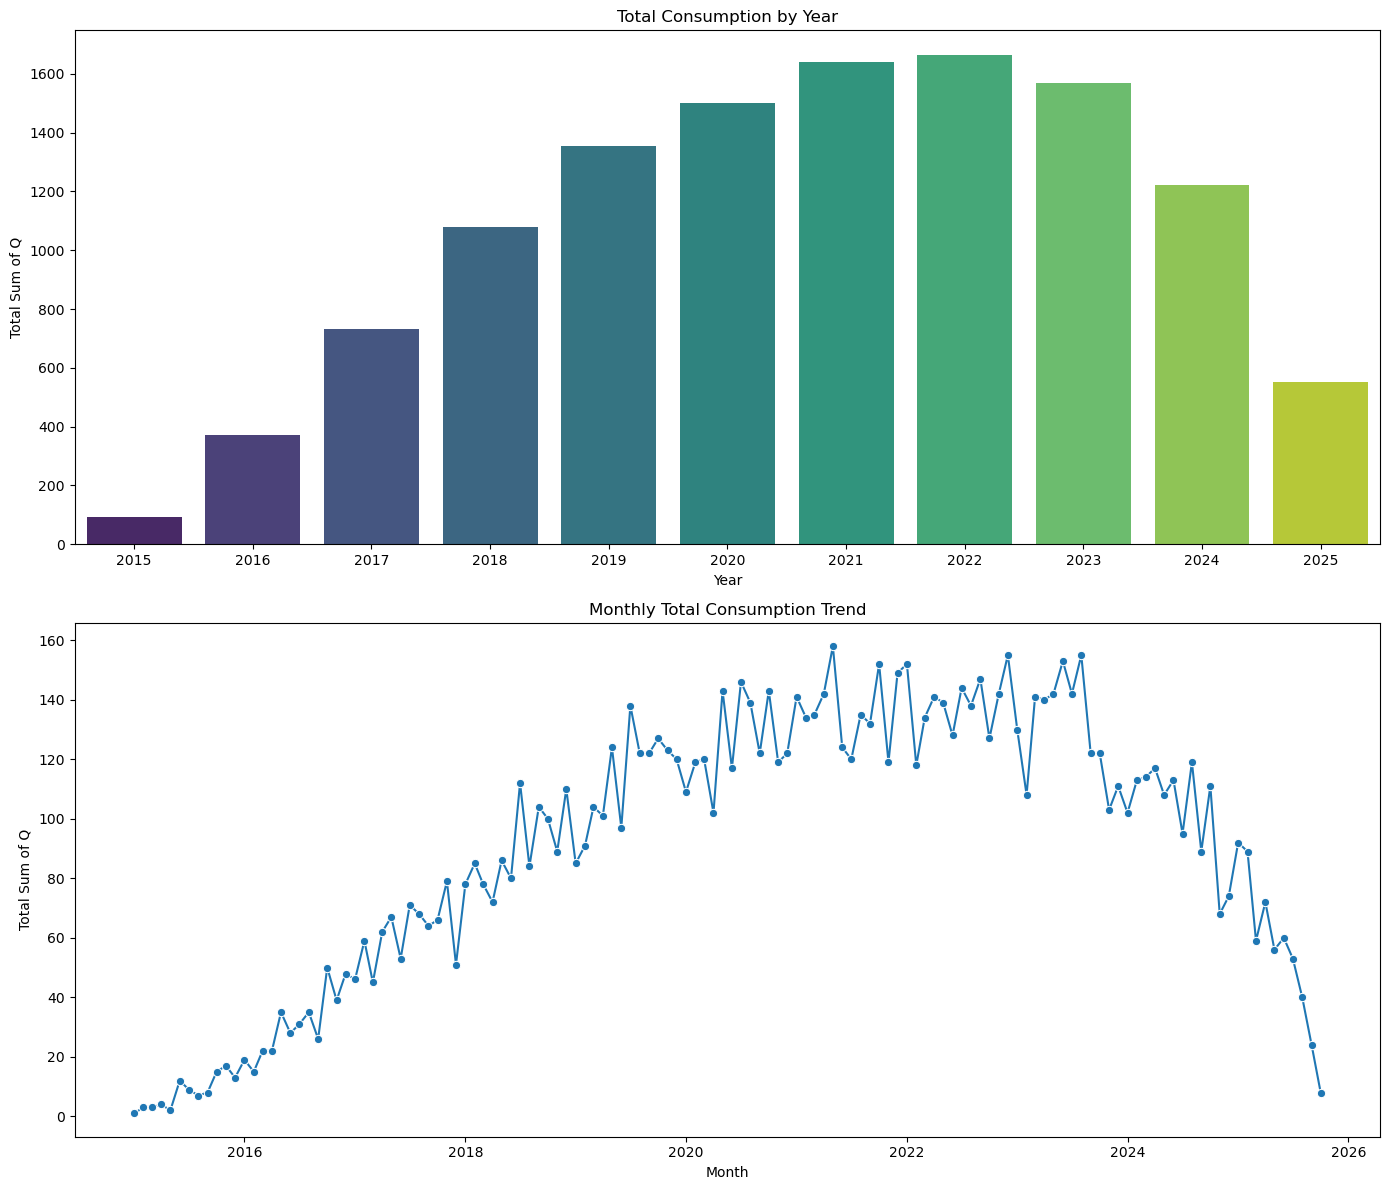

In [23]:


# Time series analysis by year and month

yearly = data.groupby('year').agg(
    total_consumption=('Sum of Q', 'sum'),
    count=('Sum of Q', 'count'),
    avg_consumption=('Sum of Q', 'mean'),
    avg_age_y=('Age (years)', 'mean')
).reset_index()

monthly = data.groupby(data["'Consumption'[Date]"].dt.to_period('M')).agg(
    total_consumption=('Sum of Q', 'sum'),
    count=('Sum of Q', 'count'),
    avg_consumption=('Sum of Q', 'mean')
).reset_index()
monthly['period'] = monthly["'Consumption'[Date]"].dt.to_timestamp()

print('Yearly consumption summary:')
display(yearly)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)
sns.barplot(data=yearly, x='year', y='total_consumption', palette='viridis', ax=axes[0])
axes[0].set_title('Total Consumption by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sum of Q')

sns.lineplot(data=monthly, x='period', y='total_consumption', marker='o', ax=axes[1])
axes[1].set_title('Monthly Total Consumption Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sum of Q')
plt.tight_layout()
plt.show()


Consumption by age bucket:


C:\Users\sivak\AppData\Local\Temp\ipykernel_9420\2384680679.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = data.groupby('age_bucket').agg(


,age_bucket,total_consumption,avg_consumption,records,avg_age
0,<1 year,12,1.090909,11,0.810909
1,1-3 years,1634,1.109301,1473,2.346680
2,3-6 years,5342,1.122269,4760,4.446462
3,6-10 years,3415,1.116013,3060,7.588196
4,10+ years,1376,1.134378,1213,13.140808


C:\Users\sivak\AppData\Local\Temp\ipykernel_9420\2384680679.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bucket_summary, x='age_bucket', y='total_consumption', palette='magma')


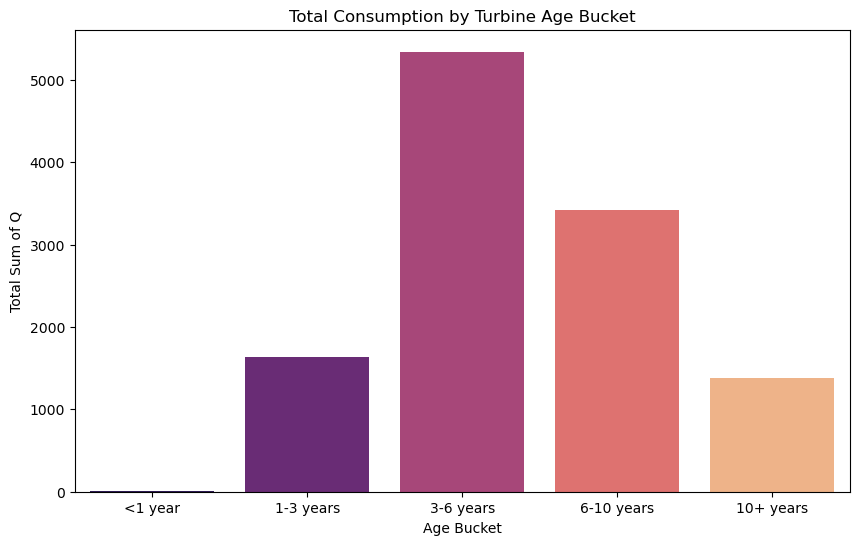

In [24]:

# Age bucket analysis

age_bins = [0, 365, 365*3, 365*6, 365*10, data['Age (d)'].max() + 1]
age_labels = ['<1 year', '1-3 years', '3-6 years', '6-10 years', '10+ years']
data['age_bucket'] = pd.cut(data['Age (d)'], bins=age_bins, labels=age_labels, right=False)
bucket_summary = data.groupby('age_bucket').agg(
    total_consumption=('Sum of Q', 'sum'),
    avg_consumption=('Sum of Q', 'mean'),
    records=('Sum of Q', 'count'),
    avg_age=('Age (years)', 'mean')
).reset_index()

print('Consumption by age bucket:')
display(bucket_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=bucket_summary, x='age_bucket', y='total_consumption', palette='magma')
plt.title('Total Consumption by Turbine Age Bucket')
plt.xlabel('Age Bucket')
plt.ylabel('Total Sum of Q')
plt.show()



Numeric correlation matrix:
             Power   Age (d)  Sum of Q
Power     1.000000 -0.017422  0.005280
Age (d)  -0.017422  1.000000  0.008623
Sum of Q  0.005280  0.008623  1.000000


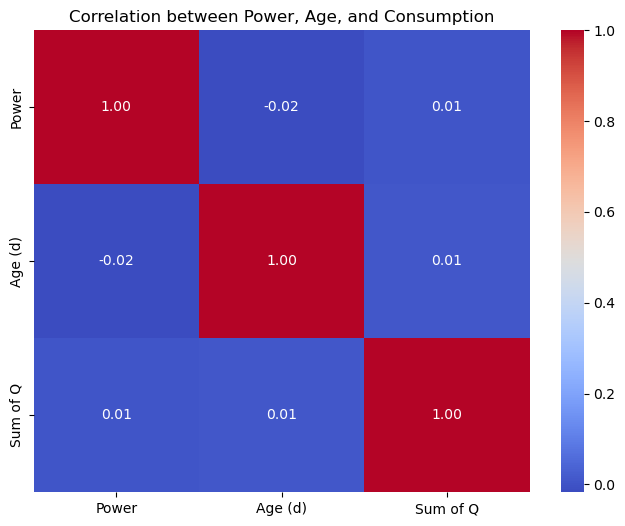

In [25]:
# Correlation matrix and outlier detection

numeric = data[['Power', 'Age (d)', 'Sum of Q']]
corr = numeric.corr()
print('Numeric correlation matrix:')
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Power, Age, and Consumption')
plt.show()


95th percentile for Sum of Q: 2.0

Top outlier records by Sum of Q:


,Country,WF,WTG,Component,Material Description,'Consumption'[Date],Age (d),Sum of Q
2474,Turkey,WFG-TU-03,88335,Pitch Converter,frequency converter Pitchmaster2+E40,2019-05-01,1314,22
3094,Turkey,WFG-TU-03,87010,Gearbox,Gearbox service component,2021-10-07,1452,22
9019,Netherlands,WFG-NE-03,88664,Pitch Converter,frequency converter Pitchmaster2+E40,2023-06-09,3415,22



Outlier counts by country:
Country
Turkey         2
Netherlands    1
Name: count, dtype: int64

Outlier counts by component:
Component
Pitch Converter    2
Gearbox            1
Name: count, dtype: int64


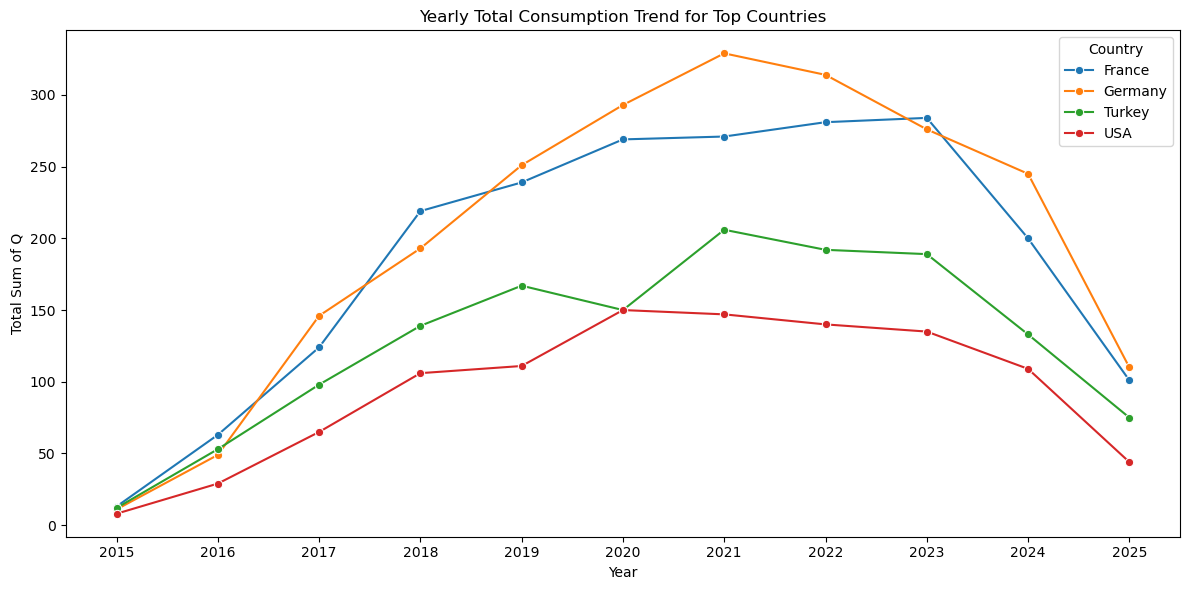

In [26]:

q95 = data['Sum of Q'].quantile(0.95)
print('95th percentile for Sum of Q:', q95)
outliers = data[data['Sum of Q'] > q95].sort_values('Sum of Q', ascending=False)
print('\nTop outlier records by Sum of Q:')
display(outliers[['Country', 'WF', 'WTG', 'Component', 'Material Description', "'Consumption'[Date]", 'Age (d)', 'Sum of Q']].head(20))
print('\nOutlier counts by country:')
print(outliers['Country'].value_counts().head(10))
print('\nOutlier counts by component:')
print(outliers['Component'].value_counts().head(10))

# Country trend for top countries

top_countries = data['Country'].value_counts().nlargest(4).index
country_trend = data[data['Country'].isin(top_countries)].groupby(['year', 'Country']).agg(
    total_consumption=('Sum of Q', 'sum')
).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=country_trend, x='year', y='total_consumption', hue='Country', marker='o')
plt.title('Yearly Total Consumption Trend for Top Countries')
plt.xlabel('Year')
plt.ylabel('Total Sum of Q')
plt.xticks(sorted(country_trend['year'].unique()))
plt.legend(title='Country')
plt.tight_layout()
plt.show()
